# Insurance Claim Fraud Analysis (EDA)

## Project Overview
This project focuses on exploratory data analysis (EDA) of insurance claim data to
identify patterns and indicators associated with fraudulent claims.


## Objective
- Understand the structure and quality of the data
- Explore relationships between customer, policy, and claim attributes
- Identify variables that may signal potential fraud

In [3]:
# Importing Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [4]:
# Loading data set from GitHub

url = 'https://raw.githubusercontent.com/PavithraThantry-1998/insurance-claim-analysis-eda/refs/heads/main/data/raw_insurance_claims_fraud.csv'
df = pd.read_csv(url)

In [5]:
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,insured_occupation,insured_hobbies,insured_relationship,capital-gains,capital-loss,incident_date,incident_type,collision_type,incident_severity,authorities_contacted,incident_state,incident_city,incident_location,incident_hour_of_the_day,number_of_vehicles_involved,property_damage,bodily_injuries,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,MALE,MD,craft-repair,sleeping,husband,53300,0,2015-01-25,Single Vehicle Collision,Side Collision,Major Damage,Police,SC,Columbus,9935 4th Drive,5,1,YES,1,2,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,MALE,MD,machine-op-inspct,reading,other-relative,0,0,2015-01-21,Vehicle Theft,?,Minor Damage,Police,VA,Riverwood,6608 MLK Hwy,8,1,?,0,0,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,FEMALE,PhD,sales,board-games,own-child,35100,0,2015-02-22,Multi-vehicle Collision,Rear Collision,Minor Damage,Police,NY,Columbus,7121 Francis Lane,7,3,NO,2,3,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,FEMALE,PhD,armed-forces,board-games,unmarried,48900,-62400,2015-01-10,Single Vehicle Collision,Front Collision,Major Damage,Police,OH,Arlington,6956 Maple Drive,5,1,?,1,2,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,MALE,Associate,sales,board-games,unmarried,66000,-46000,2015-02-17,Vehicle Theft,?,Minor Damage,NaN,NY,Arlington,3041 3rd Ave,20,1,NO,0,1,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


## # Data Overview

In [6]:
# Data Overview

df.shape

(1000, 40)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

**Observations:**
* There are 1000 entries and 40 columns(variables)
* Claim amount can be understood through variables - total_claim_amount, injury_claim, property_claim, vehicle_claim.
* Fraud behaviour is recorded as 'fraud_reported' (Object variable)
* 'authorities_contacted' variable has 91  null entries
* '_c39' variable - all the enteries are null.
* Object variables are to be checked for presence of special characters. Since '?' have been spotted in some variable's entries.
* Variable type to be changed for 'incident_date' and 'policy_bind_date' from object to data type.


In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
months_as_customer,1000.0,2.039540e+02,1.151132e+02,0.00,115.7500,199.5,276.250,479.00
age,1000.0,3.894800e+01,9.140287e+00,19.00,32.0000,38.0,44.000,64.00
policy_number,1000.0,5.462386e+05,2.570630e+05,100804.00,335980.2500,533135.0,759099.750,999435.00
policy_deductable,1000.0,1.136000e+03,6.118647e+02,500.00,500.0000,1000.0,2000.000,2000.00
policy_annual_premium,1000.0,1.256406e+03,2.441674e+02,433.33,1089.6075,1257.2,1415.695,2047.59
umbrella_limit,1000.0,1.101000e+06,2.297407e+06,-1000000.00,0.0000,0.0,0.000,10000000.00
insured_zip,1000.0,5.012145e+05,7.170161e+04,430104.00,448404.5000,466445.5,603251.000,620962.00
capital-gains,1000.0,2.512610e+04,2.787219e+04,0.00,0.0000,0.0,51025.000,100500.00
capital-loss,1000.0,-2.679370e+04,2.810410e+04,-111100.00,-51500.0000,-23250.0,0.000,0.00
incident_hour_of_the_day,1000.0,1.164400e+01,6.951373e+00,0.00,6.0000,12.0,17.000,23.00


**Observations:**

**Anomalies:**
* umbrella_limit has negative values to be further checked.
* insured_zip should it be treated as object variable ?
* auto_year to be converted date_type

In [24]:
np.sort(df['witnesses'].unique())

array([0, 1, 2, 3])

In [23]:
np.sort(df['bodily_injuries'].unique())

array([0, 1, 2])

In [22]:
np.sort(df['number_of_vehicles_involved'].unique())

array([1, 2, 3, 4])

In [17]:
df['incident_hour_of_the_day'].nunique()

24

In [18]:
np.sort(df['incident_hour_of_the_day'].unique())

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23])

In [15]:
np.sort(df['months_as_customer'].unique())

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  19,  20,  22,  24,  25,  26,  27,  29,
        30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,  43,
        45,  46,  47,  48,  50,  51,  53,  54,  55,  56,  57,  58,  59,
        60,  61,  62,  63,  64,  65,  66,  67,  69,  70,  72,  73,  75,
        76,  77,  78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,
        89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101,
       102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114,
       115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127,
       128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 140, 141,
       142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154,
       155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167,
       168, 169, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 182,
       183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 19

In [9]:
df['auto_year'].value_counts()

,count
auto_year,
1995,56
1999,55
2005,54
2006,53
2011,53
2007,52
2003,51
2009,50
2010,50


In [10]:
for i in df.columns:
  if df[i].dtype == 'object':
    print('The unique categories in variable', i, 'are:')
    print(df[i].value_counts())
    print()

The unique categories in variable policy_bind_date are:
policy_bind_date
1992-08-05    3
2006-01-01    3
1992-04-28    3
1996-07-07    2
2002-07-16    2
             ..
1999-02-18    1
1997-10-30    1
1999-11-29    1
2013-07-07    1
1991-08-02    1
Name: count, Length: 951, dtype: int64

The unique categories in variable policy_state are:
policy_state
OH    352
IL    338
IN    310
Name: count, dtype: int64

The unique categories in variable policy_csl are:
policy_csl
250/500     351
100/300     349
500/1000    300
Name: count, dtype: int64

The unique categories in variable insured_sex are:
insured_sex
FEMALE    537
MALE      463
Name: count, dtype: int64

The unique categories in variable insured_education_level are:
insured_education_level
JD             161
High School    160
Associate      145
MD             144
Masters        143
PhD            125
College        122
Name: count, dtype: int64

The unique categories in variable insured_occupation are:
insured_occupation
machine-op-

In [11]:
df.duplicated().sum()

np.int64(0)

**Observations**
* There are 178, 360 and 343 missing values in collision_type, property_damage, police_report_available repsectively which are all actually enteres as'?'
* The data is of incidents that occured over the year 2015 during the Jan and Feb months , across 7 states and 7 cities.
* 'fraud_reported' is imabalanced - which is good since there are 753 Ns and 247 Ys.
* Although the months_as_customer is continuos variable treating it as categorical variable by binning into relevant groups would further help in further analysis and model building.

## Initial Data Observations from Data Overview

- Dataset contains 1000 records with 40 variables.
- Fraud status is captured in the target variable `fraud_reported`.
- Claim amount information is distributed across:
  - total_claim_amount
  - injury_claim
  - property_claim
  - vehicle_claim
- Several object variables contain missing values encoded as '?'.
- The column `_c39` contains only null values and can be dropped.
- `incident_date` and `policy_bind_date` are stored as objects and require datetime conversion.
- The target variable is imbalanced (753 non-fraud vs 247 fraud cases), reflecting real-world fraud patterns.

## Data Cleaning

In [ ]:
# Data Cleaning

# 1. Replace '?' with NaN
df.replace('?',np.nan,inplace=True)


In [ ]:
# 2. Drop fully null column
df.drop(columns=['_c39'], inplace=True)

In [ ]:
# 3. Convert date columns
df['incident_date']=pd.to_datetime(df['incident_date'])
df['policy_bind_date'] = pd.to_datetime(df['policy_bind_date'])

In [ ]:
# Verify missing values again
df.isnull().sum().sort_values(ascending=False)

,0
property_damage,360
police_report_available,343
collision_type,178
authorities_contacted,91
months_as_customer,0
age,0
policy_number,0
policy_deductable,0
policy_csl,0
policy_state,0


In [ ]:
# Convert target variable
df['fraud_reported']=df['fraud_reported'].map({'Y':1, 'N':0})

In [ ]:
# Checking Target Variable conversion
df['fraud_reported'].value_counts()

,count
fraud_reported,
0,753
1,247


In [ ]:
# Rechecking the the number of columns
len(df.columns)

39

In [ ]:
df['incident_date'].dtype

dtype('<M8[ns]')

In [ ]:
df['policy_bind_date'].dtype

dtype('<M8[ns]')

## EDA

### 1. Missing Value Analysis - Fraud Rate vs Missingness
Certain variables contain missing values encoded earlier as '?'.  
Before imputation, we explore whether missingness itself is associated with fraud.

In [ ]:
# Create Missing Flags
missing_cols = [
    'property_damage',
    'police_report_available',
    'collision_type',
    'authorities_contacted'
]

for col in missing_cols:
    df[col + '_missing'] = df[col].isnull().astype(int)

In [ ]:
# Fraud rate by missingness
for col in missing_cols:
    print(f"\nFraud rate for {col}:")
    print(df.groupby(col + '_missing')['fraud_reported'].mean())


Fraud rate for property_damage:
property_damage_missing
0    0.225000
1    0.286111
Name: fraud_reported, dtype: float64

Fraud rate for police_report_available:
police_report_available_missing
0    0.240487
1    0.259475
Name: fraud_reported, dtype: float64

Fraud rate for collision_type:
collision_type_missing
0    0.281022
1    0.089888
Name: fraud_reported, dtype: float64

Fraud rate for authorities_contacted:
authorities_contacted_missing
0    0.265127
1    0.065934
Name: fraud_reported, dtype: float64


### Missingness vs Fraud Insights

- Missingness in `property_damage` shows a slightly higher fraud rate, indicating a weak association.
- `police_report_available` shows nearly identical fraud rates for missing and non-missing values, suggesting no meaningful relationship.
- Fraud rates are significantly higher when `collision_type` is present, indicating that fraudulent claims tend to provide detailed collision information.
- Similarly, fraud rates are much higher when `authorities_contacted` is reported, suggesting that fraudulent cases may over-document incidents to appear legitimate.

### 2. Target Variable Distribution

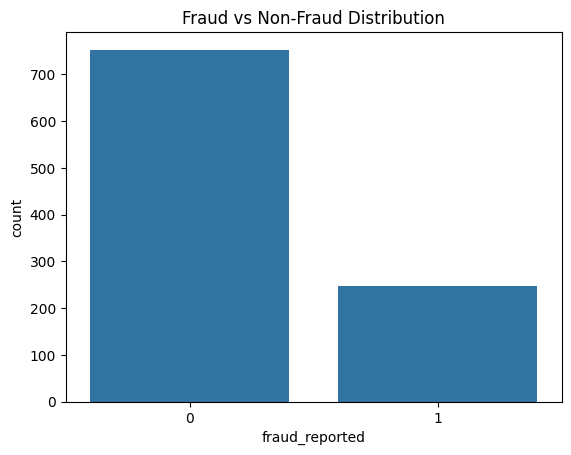

In [ ]:
plt.figure()
sns.countplot(x='fraud_reported', data=df)
plt.title('Fraud vs Non-Fraud Distribution')
plt.show()

### Fraud vs Non-Fraud Distribution

- The dataset consists of 75.3% non-fraud claims and 24.7% fraud claims, indicating a clear class imbalance.
- This imbalance suggests that future classification models developed to predict insurance fraud should account for skewed class distribution.
- Appropriate techniques such as resampling methods (oversampling or undersampling) or class-weighted algorithms may be required to avoid biased model performance.

### 3. Claim Amount Analysis

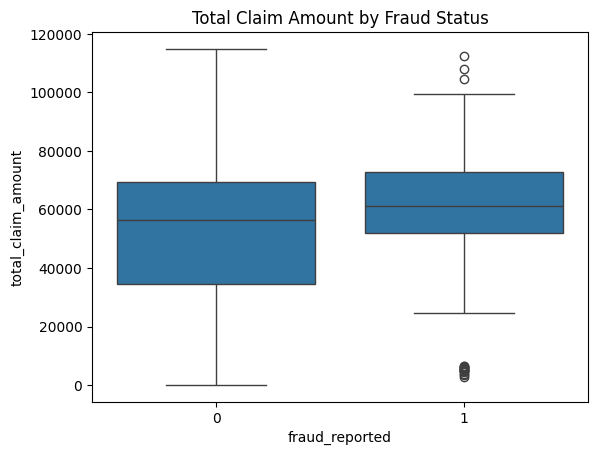

In [ ]:
plt.figure()
sns.boxplot(x='fraud_reported', y='total_claim_amount', data=df)
plt.title('Total Claim Amount by Fraud Status')
plt.show()

###

- Fraudulent claims exhibit a higher median total claim amount compared to non-fraudulent claims, indicating a tendency toward larger claim values.
- Additionally, fraud claims display a greater number of outliers, particularly at the lower end of the distribution, suggesting variability in fraudulent reporting behavior.

### 4. Categorical Variable's Univariate Analysis

### 5. Continous Variable's Univariate Analysis

### 6. Categorical Fraud Indicators

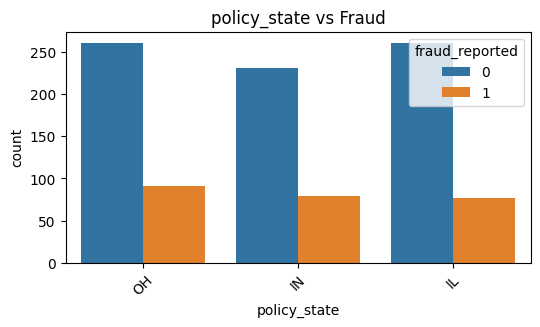

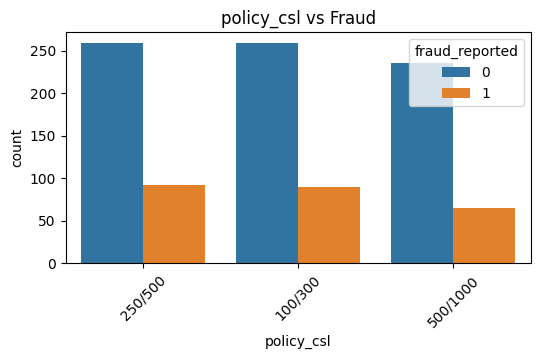

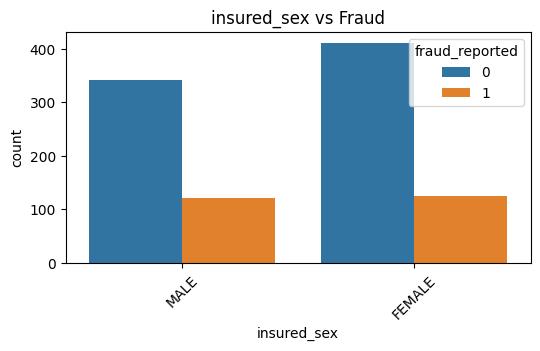

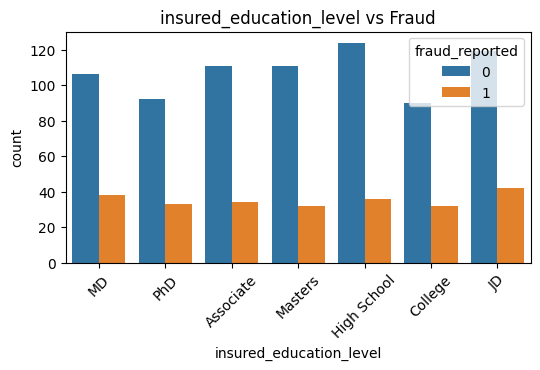

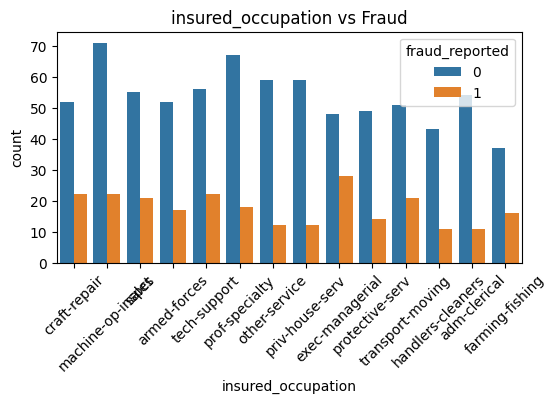

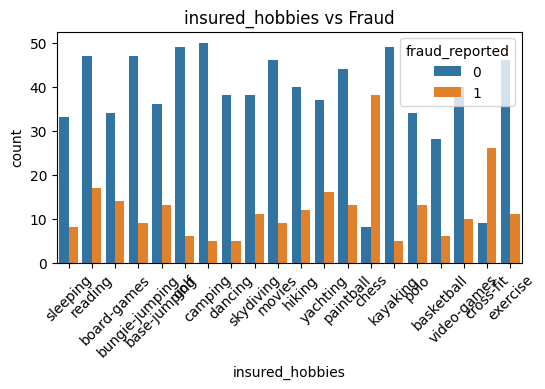

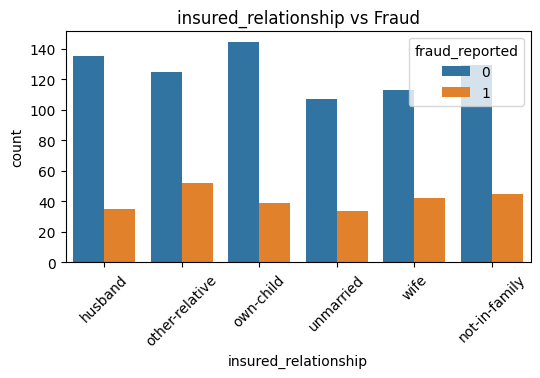

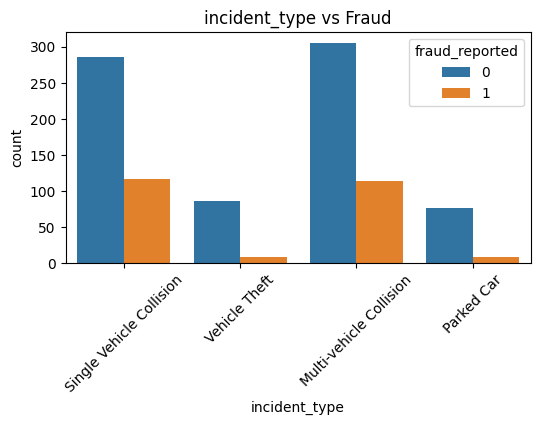

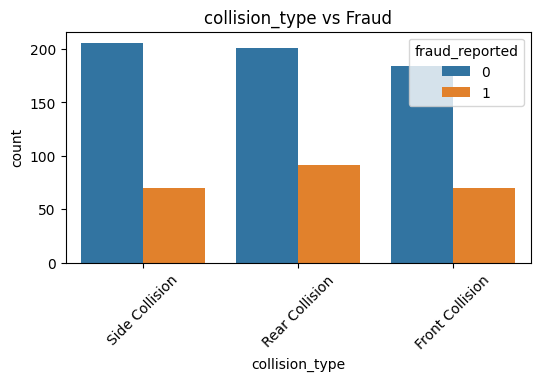

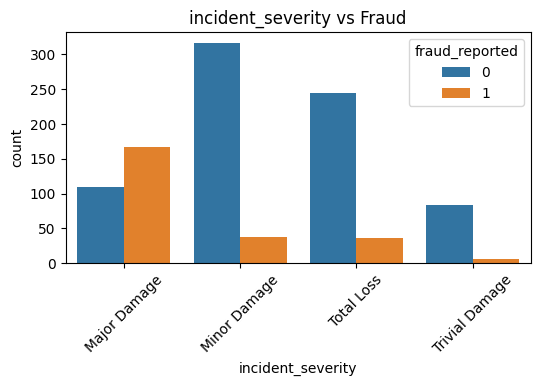

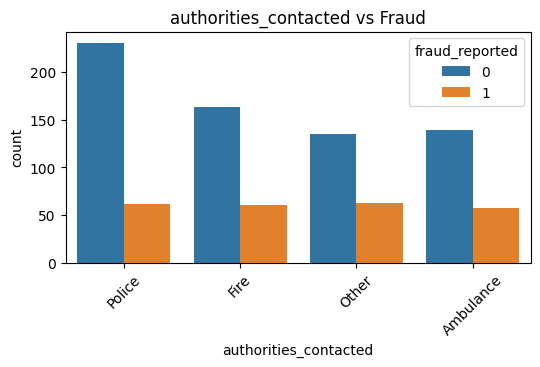

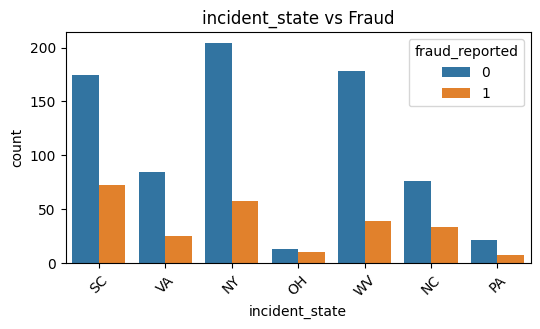

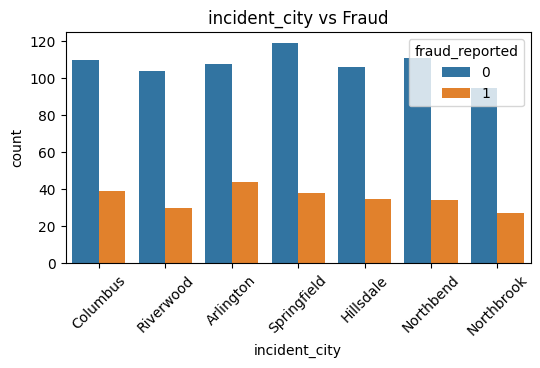

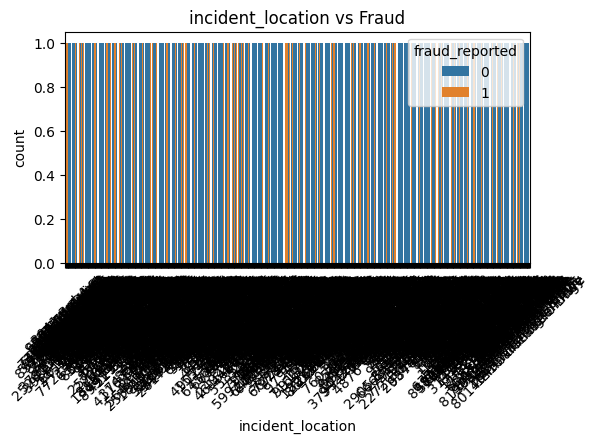

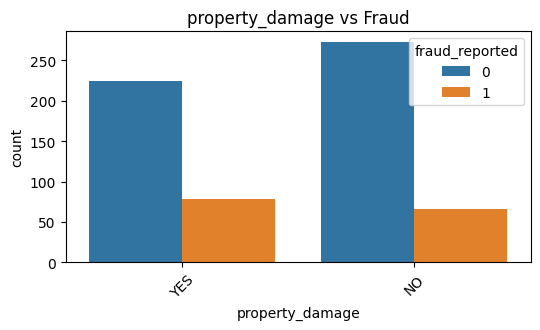

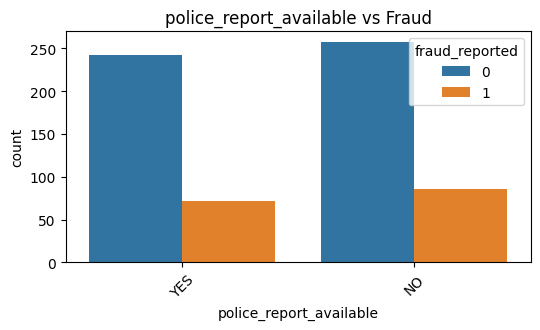

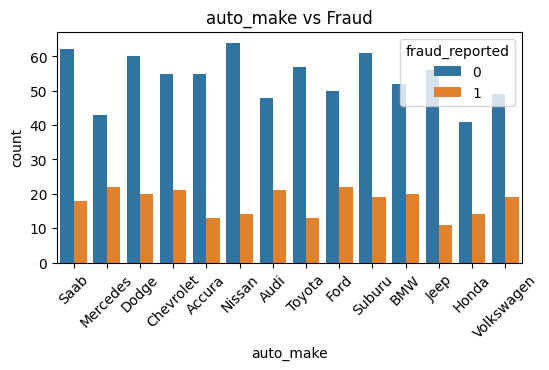

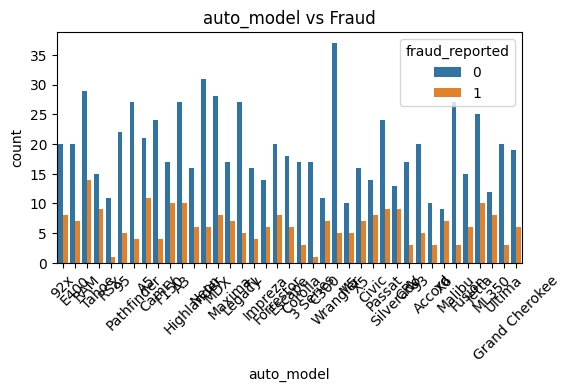

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(6,3))
    sns.countplot(data=df, x=col, hue='fraud_reported')
    plt.xticks(rotation=45)
    plt.title(f'{col} vs Fraud')
    plt.show()

### 6. Continuous Fraud Indicators

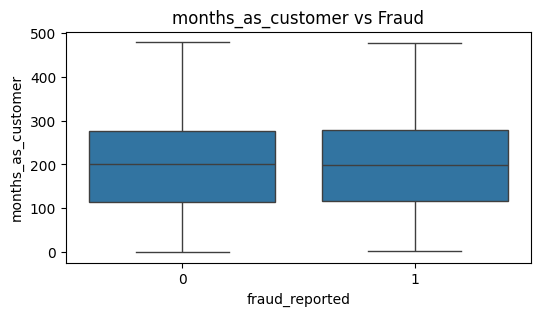

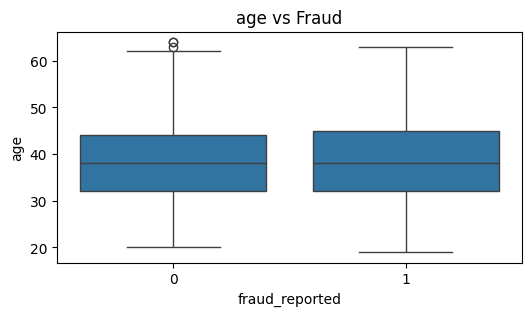

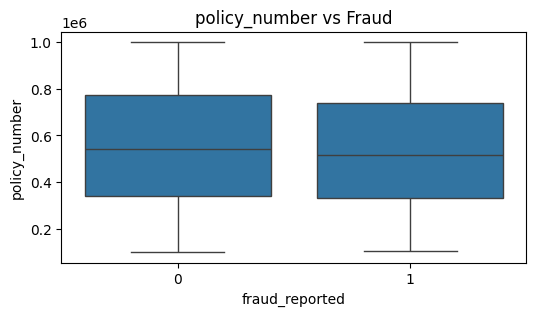

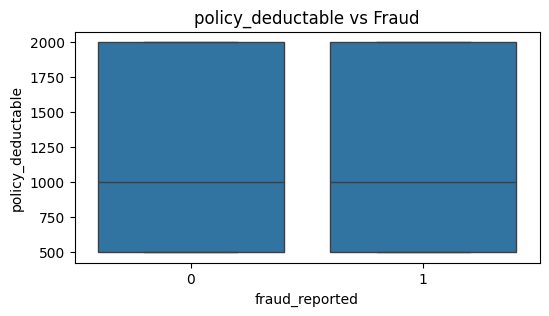

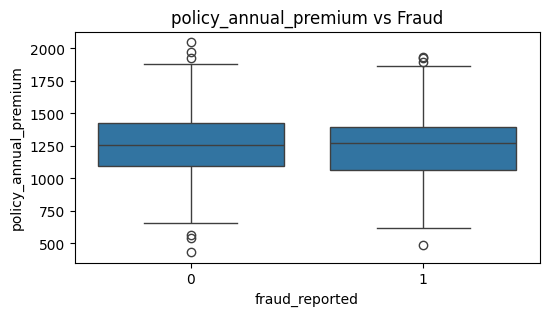

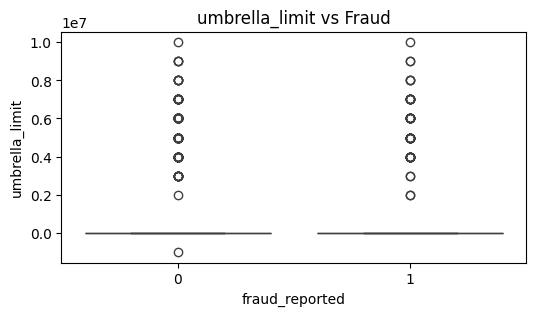

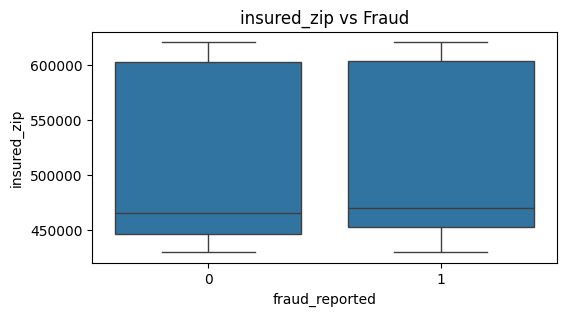

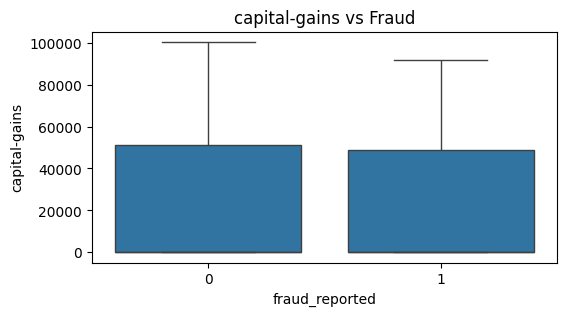

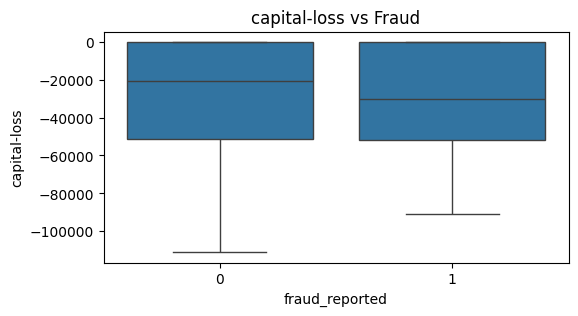

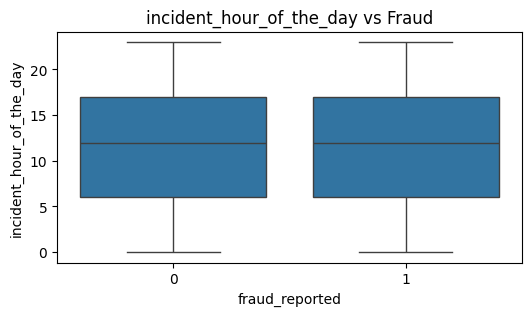

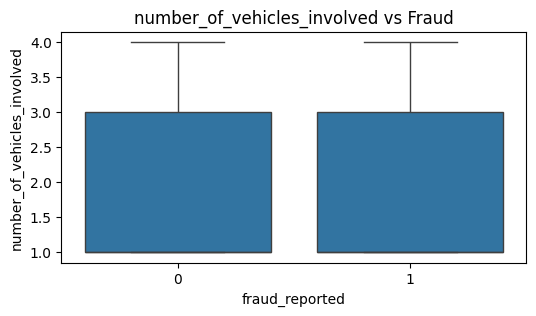

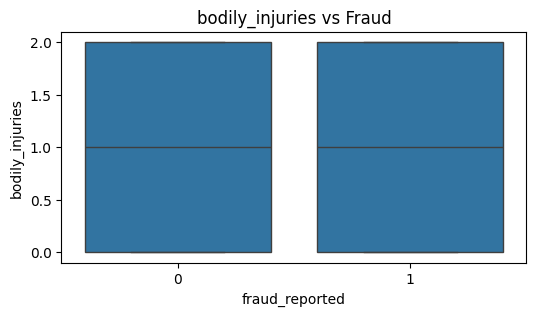

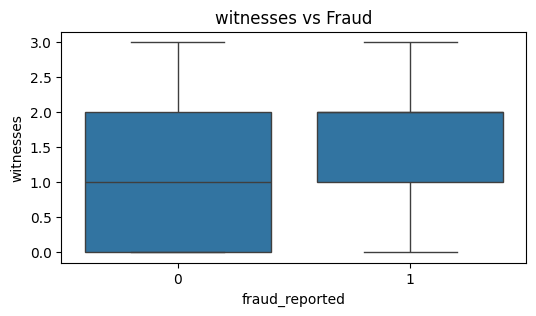

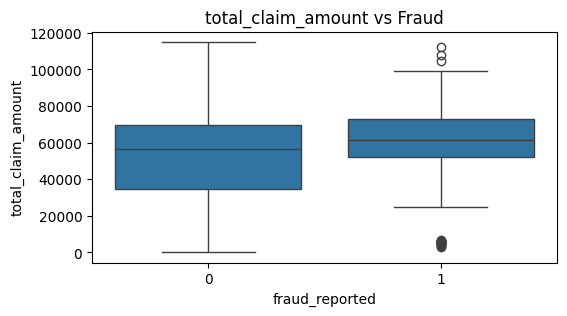

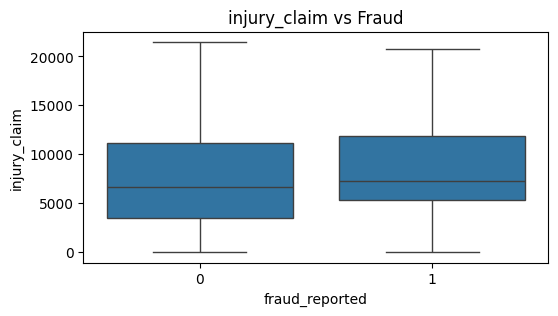

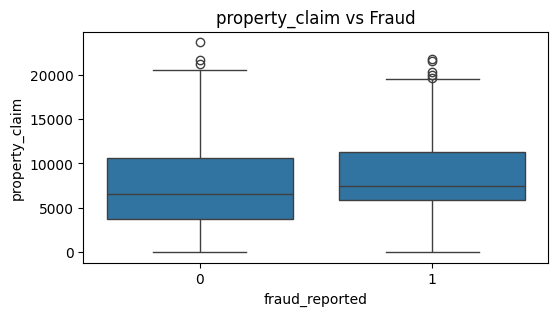

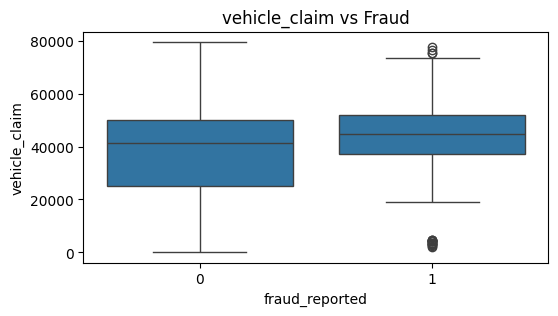

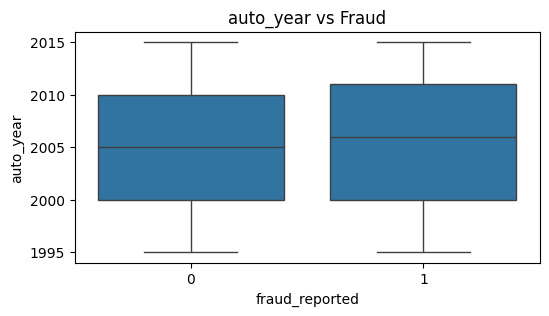

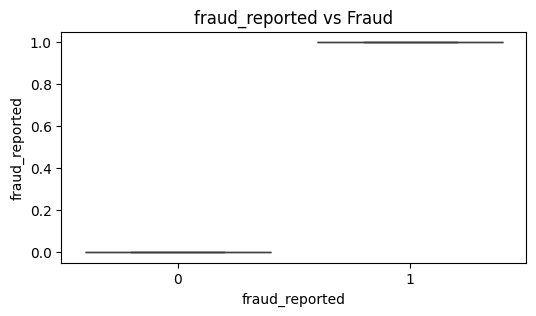

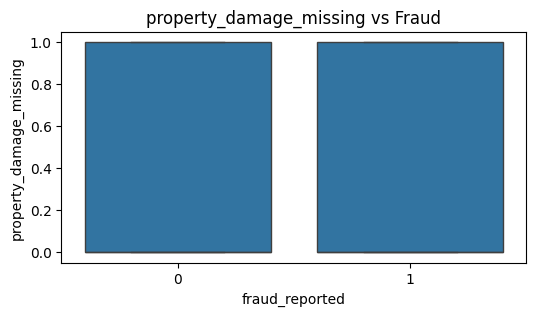

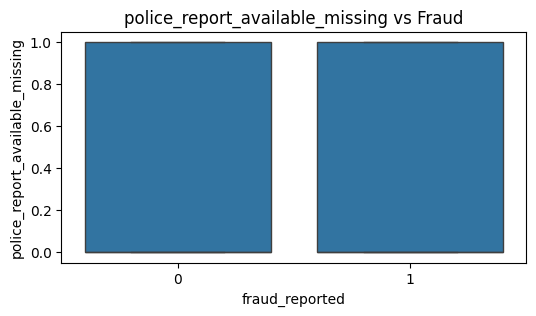

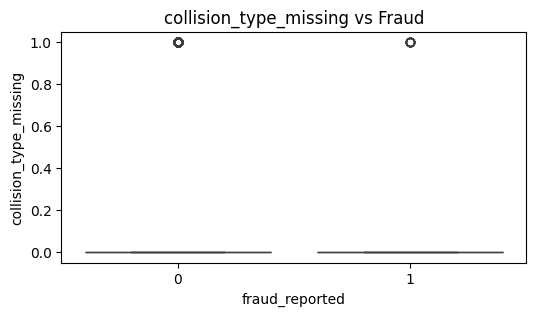

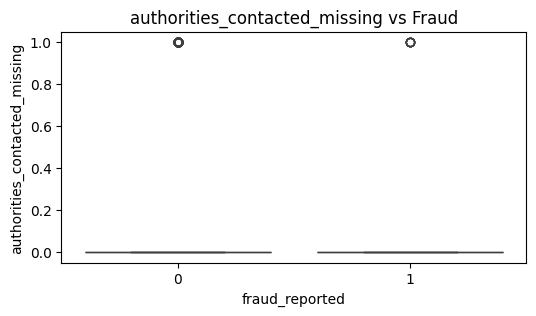

In [ ]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(data=df, x='fraud_reported', y=col)
    plt.title(f'{col} vs Fraud')
    plt.show()